# DATASET Organization
This dataset is so organized:
2 sessions

20 subjects

3 samples

5 recording

6 each recording contains 5 "tracks", one per finger, each of 25 seconds

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import wfdb
from pathlib import Path
from math import gcd
import json

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

# This function is used to:
# 1) Resample the finger force target from 100 Hz to 1000 Hz
# 2) Resample the EMG signal from 2048 to 1000 Hz
def resample_to_target_fs(x, fs_in, fs_target, axis=0):
    fs_in = int(fs_in); fs_target = int(fs_target)
    g = gcd(fs_in, fs_target)
    up = fs_target // g
    down = fs_in // g
    return signal.resample_poly(x, up, down, axis=axis)

# NONREALTIME filter used to filter the force signal after resampling
def lowpass_zero_phase(x, fs, cutoff=10, order=4):
    nyq = fs / 2
    b, a = signal.butter(order, cutoff / nyq, btype="low")
    return signal.filtfilt(b, a, x, axis=0)


In [ ]:
#@title Path definition

data_root = Path("../hyser_partial")
base_dir = data_root / "1dof_dataset"

assert base_dir.exists(), f"Cartella non trovata: {base_dir}"

# lista cartelle tipo subject01_session1 ...
subjects = sorted([p.name for p in base_dir.iterdir() if p.is_dir()])
print("N subjects/session trovati:", len(subjects))
print(subjects[:5])


N subjects/session trovati: 40
['subject01_session1', 'subject01_session2', 'subject02_session1', 'subject02_session2', 'subject03_session1']


In [ ]:
#@title Label definition

fingers = [f"finger{i}" for i in range(1, 6)]   # finger1..finger5
samples = ["sample1", "sample2", "sample3"]
fs_target = 1000

def finger_to_force_col(finger: str) -> int:
    # finger1 -> 0, finger2 -> 1, ...
    return int(finger.replace("finger", "")) - 1


In [ ]:
#@title Load EMG and Force signals
def load_emg_force(subject, finger, sample, fs_target=1000):
    emg_base   = f"1dof_raw_{finger}_{sample}"
    force_base = f"1dof_force_{finger}_{sample}"

    emg_path   = base_dir / subject / emg_base
    force_path = base_dir / subject / force_base

    emg_rec   = wfdb.rdrecord(str(emg_path))
    force_rec = wfdb.rdrecord(str(force_path))

    emg_raw   = emg_rec.p_signal            # (N_emg, 256)
    force_raw = force_rec.p_signal          # (N_force, 5) di solito
    fs_emg    = float(emg_rec.fs)
    fs_force  = float(force_rec.fs)

    emg_1000   = resample_to_target_fs(emg_raw, fs_emg, fs_target, axis=0)

    force_lp   = lowpass_zero_phase(force_raw, fs_force, cutoff=10, order=4)
    force_1000 = resample_to_target_fs(force_lp, fs_force, fs_target, axis=0)

    T = min(emg_1000.shape[0], force_1000.shape[0])
    return emg_1000[:T], force_1000[:T]


Qua sotto si potrebbe:
0) Change from Matte syle delta to Gianlu style delta (ma non è detto che sia davvero meglio)
1) fare la delta modulation sulla seconda, terza e quarta finestra visto che la prima e l'ultima non vengono considerate nella correlazione per risparmiare tempo
2) I canali con firing rate sempre alto, quindi rumorosi, vengono gestiti settando lo score a zero e il delta a 1e9.

In [ ]:
#@title Delta modulation, window correlation and best delta functions definition (DELTA MODULATOR MATTE STYLE)

def delta_modulate_1d(x, delta):
    x = np.asarray(x)
    N = len(x)
    pos = np.zeros(N, dtype=np.uint8)
    neg = np.zeros(N, dtype=np.uint8)
    delta_sample = x[0]

    for t in range(1, N):
        s = x[t]
        if s > delta_sample + delta:
            pos[t] = 1
            delta_sample = s
        elif s < delta_sample - delta:
            neg[t] = 1
            delta_sample = s
    return pos, neg

def compute_abs_corr_windows(a, b, fs, win_len_s=5, n_windows=5):
    N_total = min(len(a), len(b))
    a = a[:N_total]; b = b[:N_total]
    out = []
    for w in range(n_windows):
        i0 = int(w * win_len_s * fs)
        i1 = int((w + 1) * win_len_s * fs)
        if i1 > N_total:
            break
        aw = a[i0:i1]; bw = b[i0:i1]
        if np.std(aw) == 0 or np.std(bw) == 0:
            out.append(0.0)
        else:
            out.append(abs(np.corrcoef(aw, bw)[0, 1]))
    return np.array(out, dtype=float)

# if during the exploration a channel firing rate is too high, its delta is set so high it won't spike anymore
# This happen when the firing rate for any delta is higher than "kill_spike_rate"

def find_best_delta(
    x_emg, f_ref,
    fs=1000,
    win_len_s=5, n_windows=5,
    kernel_ms=50,
    n_deltas=20,
    min_frac=1/30, max_frac=1/3,
    min_spike_rate=0.01, max_spike_rate=0.05,
    kill_spike_rate=0.50,
    return_debug=False
):

    T = min(len(x_emg), len(f_ref), int(win_len_s * n_windows * fs))
    x_emg = np.asarray(x_emg[:T])
    f_ref = np.asarray(f_ref[:T])

    max_val = float(np.max(np.abs(x_emg)))
    if max_val == 0 or T < fs:
        return (0.0, {}) if return_debug else 0.0

    # set delta values for the exploration
    deltas = np.linspace(max_val * max_frac, max_val * min_frac, n_deltas)

    # kernel to compute firing rate
    k = max(1, int(kernel_ms * fs / 1000))
    kernel = np.ones(k, dtype=float) / k

    # it will store correlation values, one per each delta
    scores = np.zeros_like(deltas, dtype=float)
    # it will store mean firing rate, one per each delta
    spike_rates = np.zeros_like(deltas, dtype=float)

    for i, d in enumerate(deltas):
        pos, neg = delta_modulate_1d(x_emg, d)
        spikes = (pos + neg).astype(float)

        sr = float(spikes.mean())
        spike_rates[i] = sr

        if not (min_spike_rate <= sr <= max_spike_rate):
            scores[i] = 0.0
            continue

        # firing rate computation
        smoothed = np.convolve(spikes, kernel, mode="same")
        # computes CC along five movement phases, diveded considering each takes 5 seconds
        # it returns 5 CC, one per movement phase
        abs_corrs = compute_abs_corr_windows(smoothed, f_ref, fs, win_len_s, n_windows)
        # Only CC of movement is considered: 1,2,3; it thrash windows 0 and 4
        scores[i] = abs_corrs[1:4].mean() if len(abs_corrs) >= 4 else 0.0

    # compute delta modulation encoding
    pos0, neg0 = delta_modulate_1d(x_emg, deltas[0])  # deltas[0] = delta più grande
    # sum positive and negative spike channels
    sr0 = float((pos0 + neg0).mean())
    if sr0 > kill_spike_rate:
        if return_debug:
            return float(1e9), {"reason": "killed", "sr_at_max_delta": sr0, "delta_max": float(deltas[0])}
        return float(1e9)

    # se nessun delta ha score>0, fallback sul target rate (centro range)
    if np.all(scores == 0):
        target_sr = 0.5 * (min_spike_rate + max_spike_rate)
        best_idx = int(np.argmin(np.abs(spike_rates - target_sr)))
        if return_debug:
            return float(deltas[best_idx]), {
                "reason": "fallback_target_sr",
                "best_idx": best_idx,
                "target_sr": target_sr,
                "spike_rates": spike_rates,
                "deltas": deltas,
                "sr_at_max_delta": sr0
            }
        return float(deltas[best_idx])

    best_idx = int(np.argmax(scores))
    if return_debug:
        return float(deltas[best_idx]), {
            "reason": "score_max",
            "best_idx": best_idx,
            "score": float(scores[best_idx]),
            "sr": float(spike_rates[best_idx]),
            "spike_rates": spike_rates,
            "deltas": deltas,
            "sr_at_max_delta": sr0
        }
    return float(deltas[best_idx])

## **Ridurre esplorazione a un solo sample**

In [ ]:
#@title Exploration execution: delta selected only on the base of the track where that finger is supposed to excercise force

# parametri sweep
fs = fs_target
win_len_s = 5
n_windows = 5
kernel_ms = 50
n_deltas = 20
min_frac = 1/30
max_frac = 1/3
min_spike_rate = 0.01
max_spike_rate = 0.05

# output of the exploration: 1 delta per channel
output_json = "best_deltas_per_subject_session_finger_sample.json"

delta_results = {}  # subj -> finger -> sample -> deltas[256]

for subj in subjects:
    print(f"\n### {subj}")
    delta_results[subj] = {}

    for finger in fingers:
        print(f"  ▶ {finger}")
        delta_results[subj][finger] = {}

        # it returns 0 for finger1, 1 for finger2, etc..
        force_col = finger_to_force_col(finger)

        for samp in samples:
            print(f"    ▷ {samp}")
            try:
                X_emg, F_force = load_emg_force(subj, finger, samp, fs_target=fs)
                T = min(X_emg.shape[0], F_force.shape[0])
                X_emg = X_emg[:T]
                F_force = F_force[:T]

                f_ref = F_force[:, force_col]
                C = X_emg.shape[1]
                deltas_ch = np.zeros(C, dtype=float)

                for ch in range(C):
                    deltas_ch[ch] = find_best_delta(
                        X_emg[:, ch], f_ref,
                        fs=fs,
                        win_len_s=win_len_s, n_windows=n_windows,
                        kernel_ms=kernel_ms,
                        n_deltas=n_deltas,
                        min_frac=min_frac, max_frac=max_frac,
                        min_spike_rate=min_spike_rate, max_spike_rate=max_spike_rate,
                    )
                    if ch % 64 == 0:
                        print(f"      ch {ch:3d}/{C} δ={deltas_ch[ch]:.6f}")

                delta_results[subj][finger][samp] = deltas_ch.tolist()

            except Exception as e:
                print(f"      ⚠ ERRORE {subj} {finger} {samp}: {e}")

to_save = {
    "config": dict(
        fs=fs, fs_target=fs_target,
        subjects=subjects, fingers=fingers, samples=samples,
        win_len_s=win_len_s, n_windows=n_windows,
        kernel_ms=kernel_ms,
        n_deltas=n_deltas,
        min_frac=float(min_frac), max_frac=float(max_frac),
        min_spike_rate=float(min_spike_rate), max_spike_rate=float(max_spike_rate),
    ),
    "deltas": delta_results
}

with open(output_json, "w") as f:
    json.dump(to_save, f, indent=2)

print("\nSalvato:", output_json)



### subject01_session1
  ▶ finger1
    ▷ sample1
      ch   0/256 δ=0.096167
      ch  64/256 δ=0.332468
      ch 128/256 δ=0.063047
      ch 192/256 δ=0.077566
    ▷ sample2
      ch   0/256 δ=0.081555
      ch  64/256 δ=0.334690
      ch 128/256 δ=0.061211
      ch 192/256 δ=0.070472
    ▷ sample3
      ch   0/256 δ=0.087711
      ch  64/256 δ=0.330420
      ch 128/256 δ=0.055755
      ch 192/256 δ=0.081987
  ▶ finger2
    ▷ sample1
      ch   0/256 δ=0.059755
      ch  64/256 δ=0.195898
      ch 128/256 δ=0.049045
      ch 192/256 δ=0.063732
    ▷ sample2
      ch   0/256 δ=0.052444
      ch  64/256 δ=0.218656
      ch 128/256 δ=0.047301
      ch 192/256 δ=0.046258
    ▷ sample3
      ch   0/256 δ=0.054223
      ch  64/256 δ=0.190939
      ch 128/256 δ=0.047015
      ch 192/256 δ=0.056511
  ▶ finger3
    ▷ sample1
      ch   0/256 δ=0.056986
      ch  64/256 δ=0.201361
      ch 128/256 δ=0.060601
      ch 192/256 δ=0.069040
    ▷ sample2
      ch   0/256 δ=0.040862
      ch  64/256

In [ ]:
#@title The final delta of each channel is set by computing the mean of each delta selected on the three samples

agg_json = "best_deltas_per_subject_session_finger_AGGmedian.json"

with open(output_json, "r") as f:
    data = json.load(f)

delta_map = data["deltas"]

delta_agg = {}  # subj -> finger -> deltas[256] (mediana sui sample disponibili)
for subj in subjects:
    delta_agg[subj] = {}
    for finger in fingers:
        mats = []
        for samp in samples:
            if samp in delta_map.get(subj, {}).get(finger, {}):
                mats.append(np.array(delta_map[subj][finger][samp], dtype=float))
        if len(mats) == 0:
            continue
        M = np.stack(mats, axis=0)  # (n_samples, 256)
        delta_agg[subj][finger] = np.median(M, axis=0).tolist()

with open(agg_json, "w") as f:
    json.dump({"config": data["config"], "deltas": delta_agg}, f, indent=2)

print("Salvato aggregato:", agg_json)


🎉 Salvato aggregato: best_deltas_per_subject_session_finger_AGGmedian.json


In [ ]:
#@title Store spikes for training in .npz

spike_root = data_root / "spike_maps_updated_2"
spike_root.mkdir(parents=True, exist_ok=True)

with open(agg_json, "r") as f:
    data_agg = json.load(f)

delta_agg_map = data_agg["deltas"]
fs = data_agg["config"]["fs"]

for subj in subjects:
    for finger in fingers:
        if finger not in delta_agg_map.get(subj, {}):
            continue
        deltas = np.array(delta_agg_map[subj][finger], dtype=float)

        for samp in samples:
            try:
                X_emg, F_force = load_emg_force(subj, finger, samp, fs_target=fs)
                T, C = X_emg.shape
                if len(deltas) != C:
                    raise ValueError(f"deltas len={len(deltas)} != n_chan={C}")

                pos_all = np.zeros((T, C), dtype=np.uint8)
                neg_all = np.zeros((T, C), dtype=np.uint8)

                for ch in range(C):
                    pos, neg = delta_modulate_1d(X_emg[:, ch], deltas[ch])
                    pos_all[:, ch] = pos
                    neg_all[:, ch] = neg

                out_path = spike_root / f"spikes_{subj}_{finger}_{samp}.npz"
                np.savez_compressed(
                    out_path,
                    pos=pos_all, neg=neg_all,
                    deltas=deltas, fs=fs,
                    subject=subj, finger=finger, sample=samp
                )
                print("✅", out_path.name)

            except Exception as e:
                print(f"❌ {subj} {finger} {samp}: {e}")


✅ spikes_subject01_session1_finger1_sample1.npz
✅ spikes_subject01_session1_finger1_sample2.npz
✅ spikes_subject01_session1_finger1_sample3.npz
✅ spikes_subject01_session1_finger2_sample1.npz
✅ spikes_subject01_session1_finger2_sample2.npz
✅ spikes_subject01_session1_finger2_sample3.npz
✅ spikes_subject01_session1_finger3_sample1.npz
✅ spikes_subject01_session1_finger3_sample2.npz
✅ spikes_subject01_session1_finger3_sample3.npz
✅ spikes_subject01_session1_finger4_sample1.npz
✅ spikes_subject01_session1_finger4_sample2.npz
✅ spikes_subject01_session1_finger4_sample3.npz
✅ spikes_subject01_session1_finger5_sample1.npz
✅ spikes_subject01_session1_finger5_sample2.npz
✅ spikes_subject01_session1_finger5_sample3.npz
✅ spikes_subject01_session2_finger1_sample1.npz
✅ spikes_subject01_session2_finger1_sample2.npz
✅ spikes_subject01_session2_finger1_sample3.npz
✅ spikes_subject01_session2_finger2_sample1.npz
✅ spikes_subject01_session2_finger2_sample2.npz
✅ spikes_subject01_session2_finger2_samp

Sto plottando forza colonna: 1 per finger2


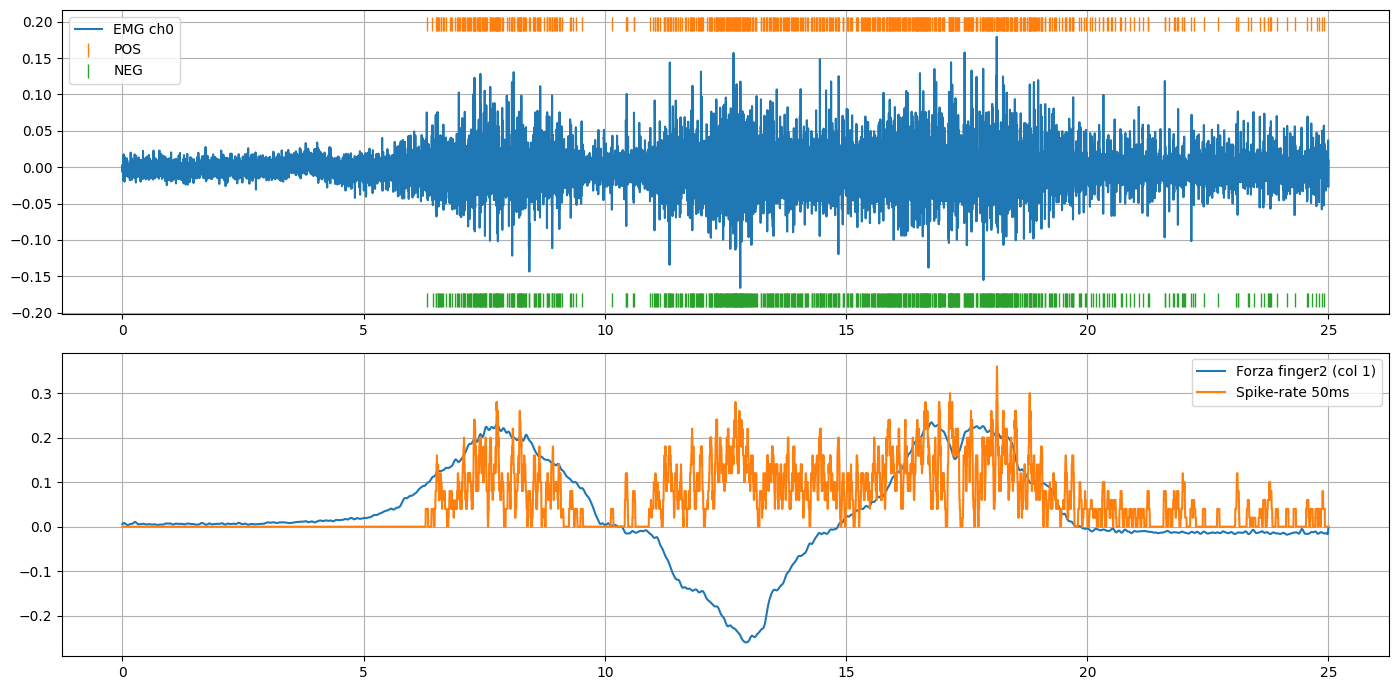

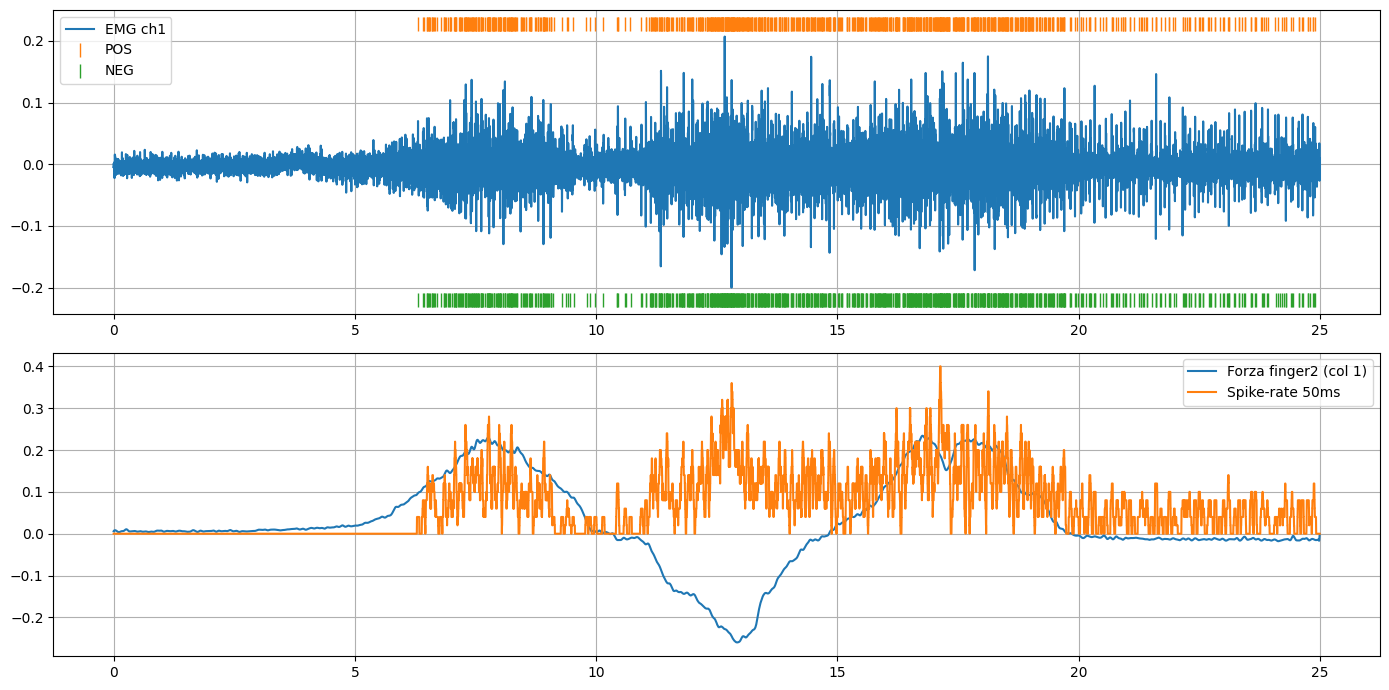

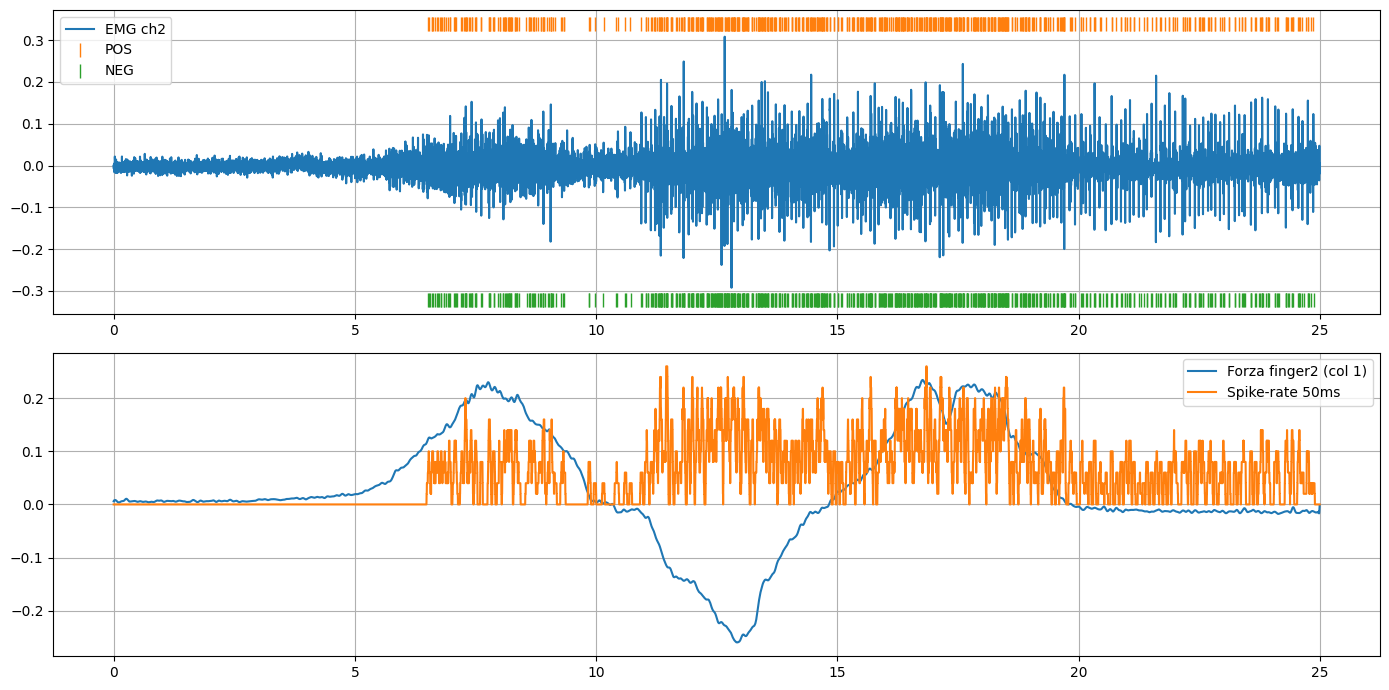

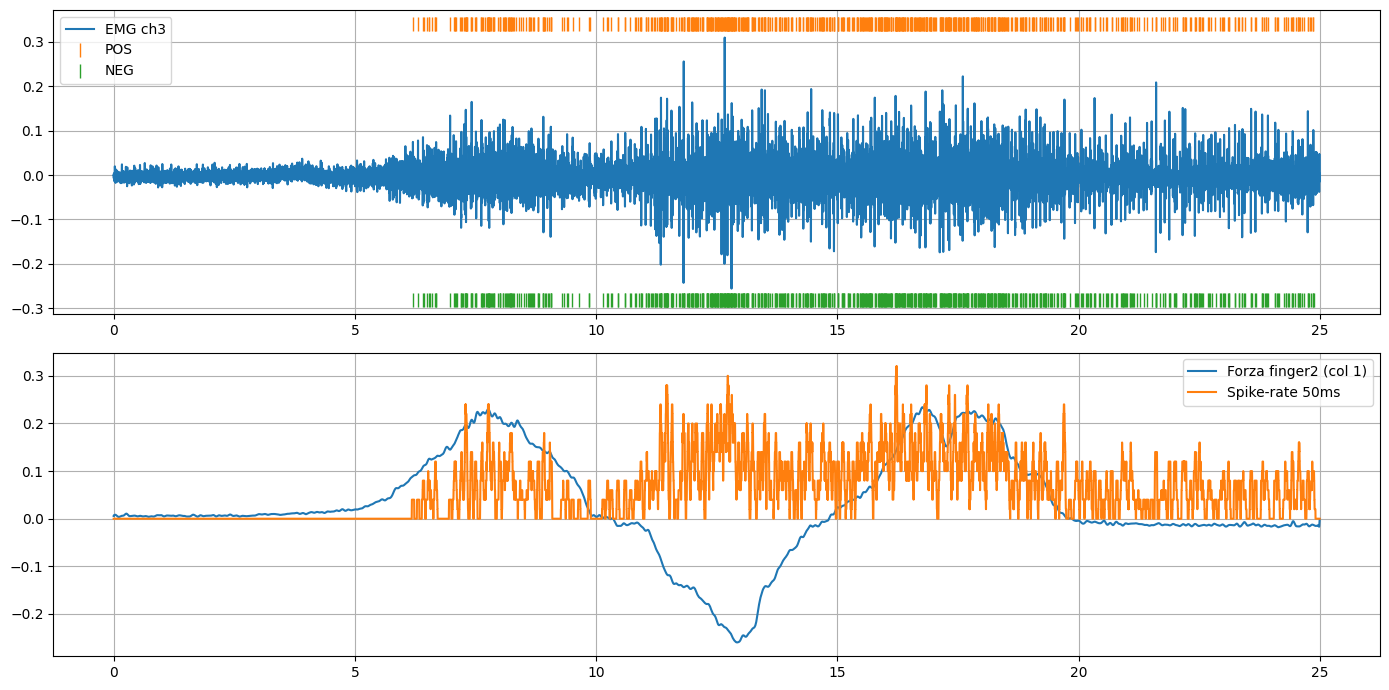

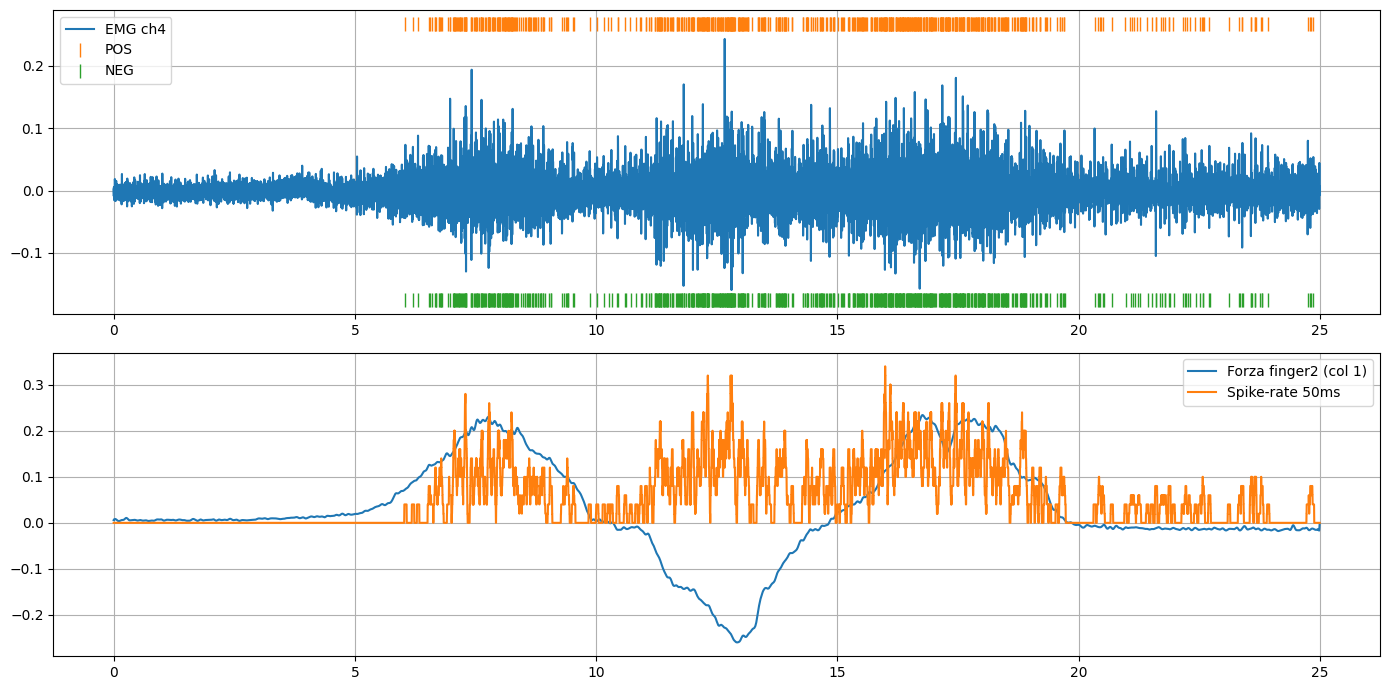

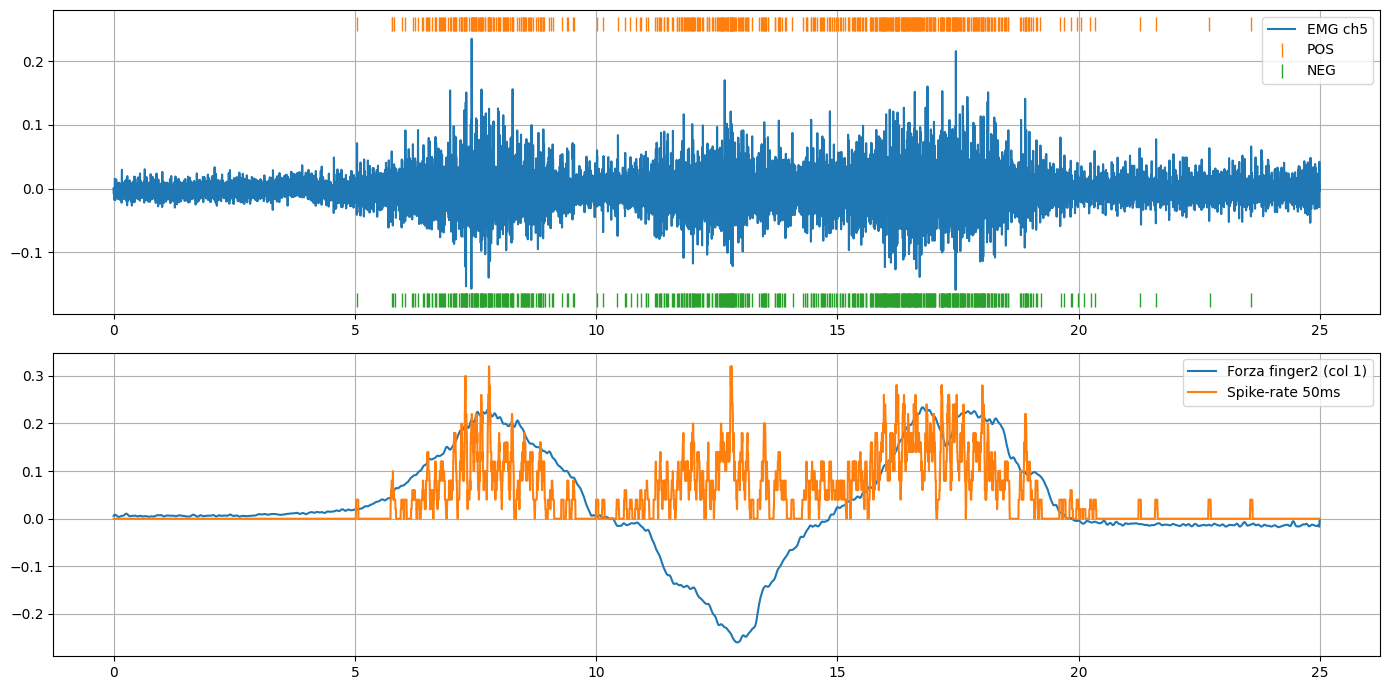

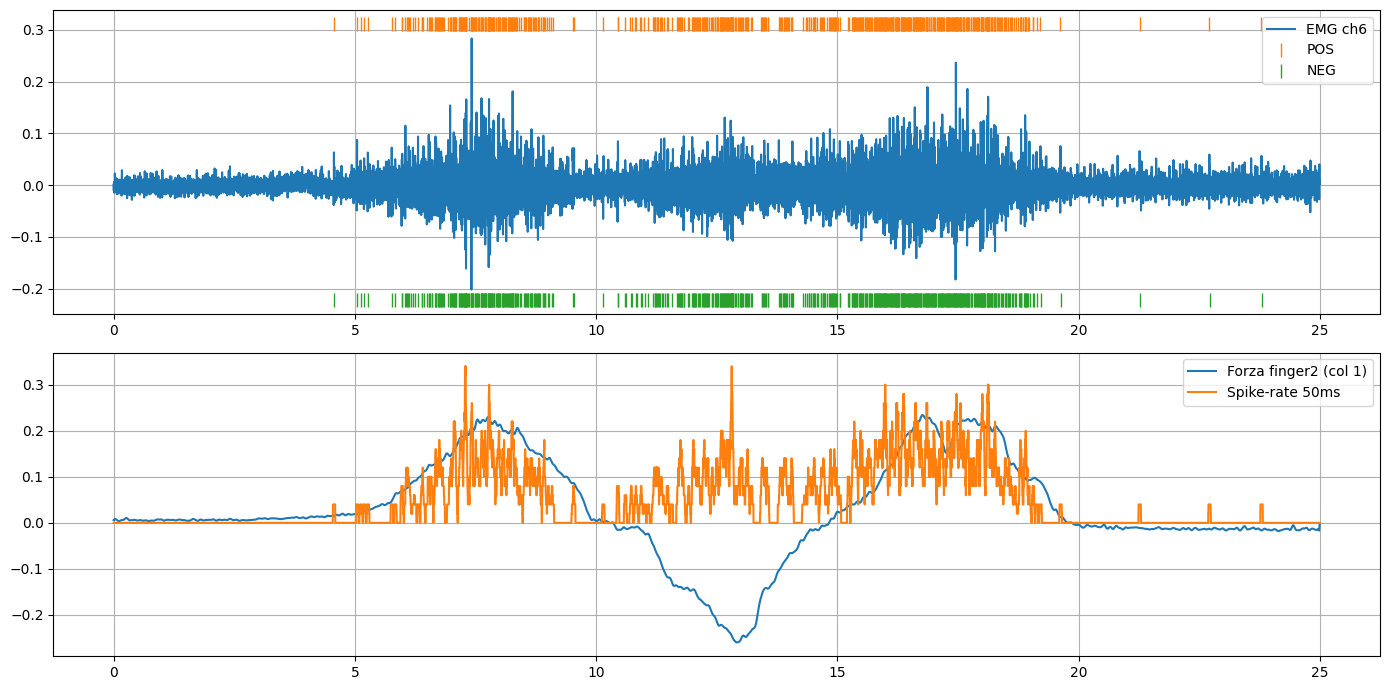

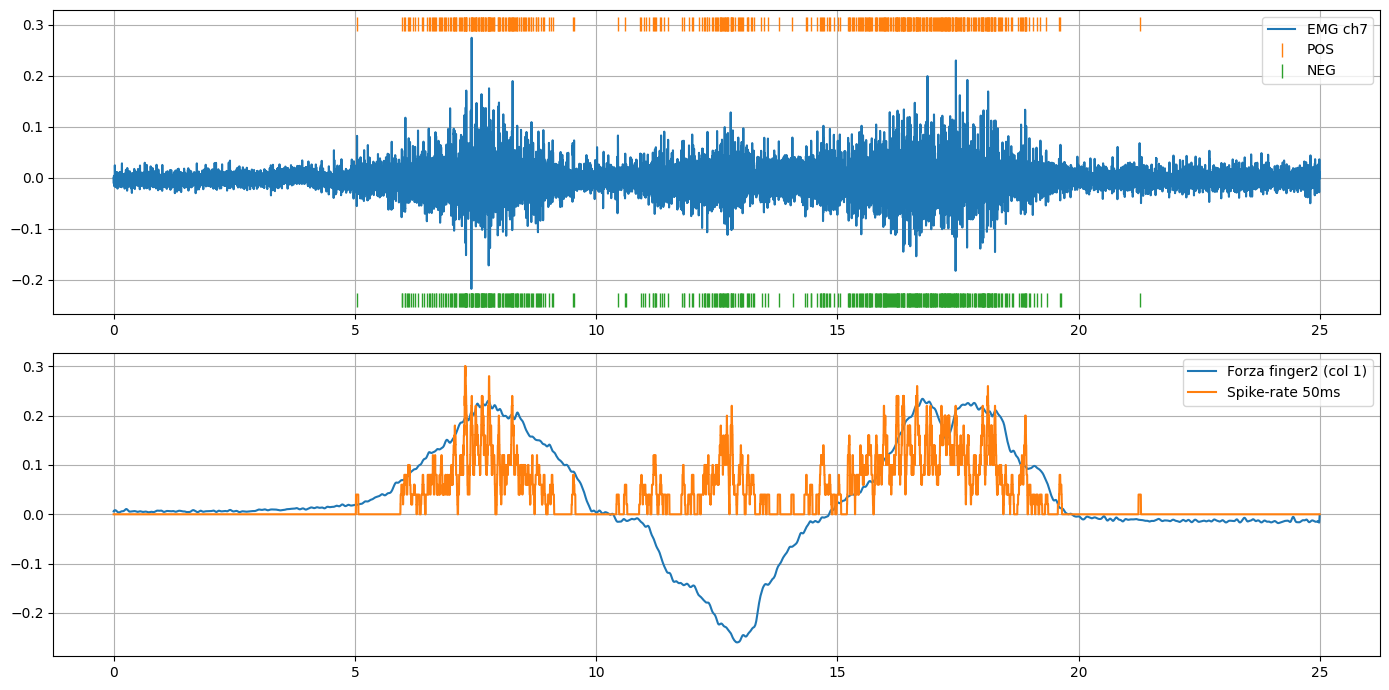

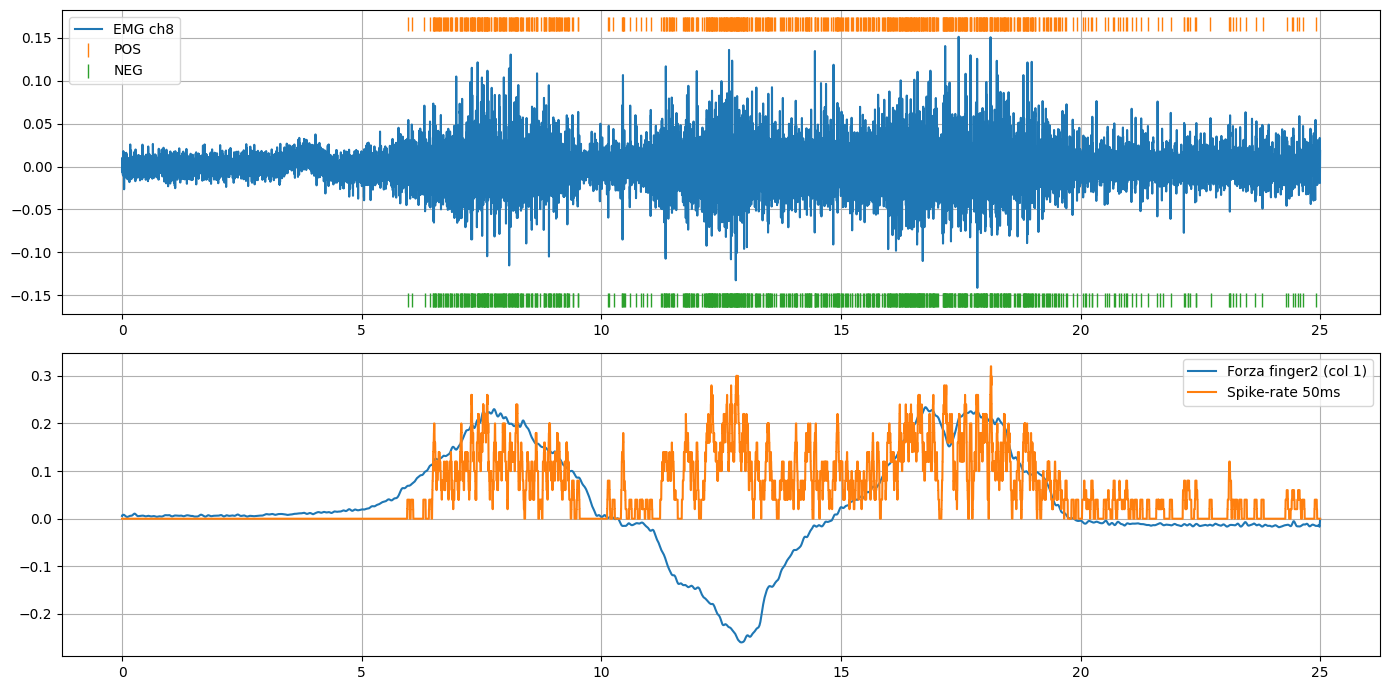

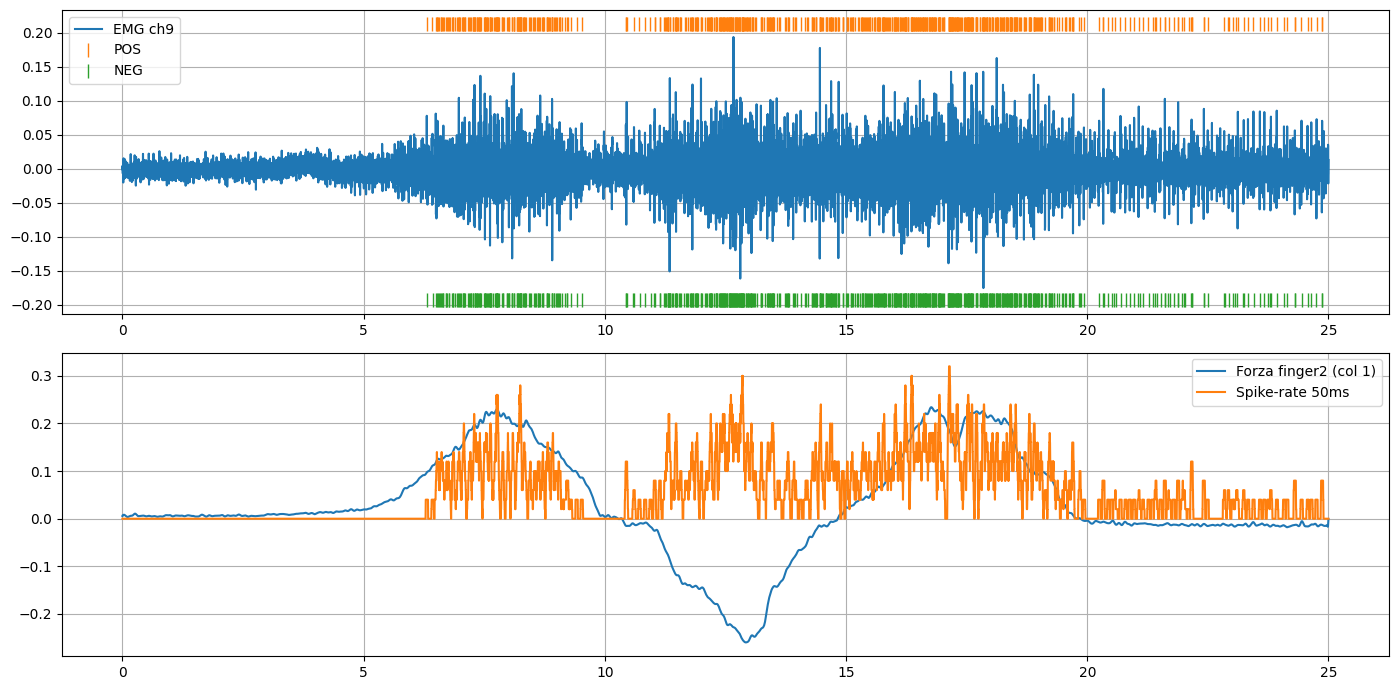

In [ ]:
subject_to_view = subjects[0]
finger_to_view  = "finger2"
sample_to_view  = "sample1"

ch_force = finger_to_force_col(finger_to_view)
fs = 1000
t_start, t_end = 0.0, 25.0
channels_to_plot = list(range(10))

with open(agg_json, "r") as f:
    d = json.load(f)
best_deltas = np.array(d["deltas"][subject_to_view][finger_to_view], dtype=float)

X_emg, F_force = load_emg_force(subject_to_view, finger_to_view, sample_to_view, fs_target=fs)
T = min(X_emg.shape[0], F_force.shape[0])
X_emg = X_emg[:T]; F_force = F_force[:T]

i0 = int(t_start * fs); i1 = min(int(t_end * fs), T)
t = np.arange(T) / fs
t_win = t[i0:i1]
f_chan = F_force[i0:i1, ch_force]

kernel_ms = 50
k = max(1, int(kernel_ms * fs / 1000))
kernel = np.ones(k) / k

print("Sto plottando forza colonna:", ch_force, "per", finger_to_view)

for ch in channels_to_plot:
    x = X_emg[i0:i1, ch]
    pos, neg = delta_modulate_1d(x, best_deltas[ch])
    spike_rate = np.convolve((pos+neg).astype(float), kernel, mode="same")

    plt.figure(figsize=(14, 7))
    ax1 = plt.subplot(2,1,1)
    ax1.plot(t_win, x, label=f"EMG ch{ch}")
    ax1.plot(t_win[pos==1], np.full(np.sum(pos==1), np.max(x)*1.1), '|', markersize=10, label="POS")
    ax1.plot(t_win[neg==1], np.full(np.sum(neg==1), np.min(x)*1.1), '|', markersize=10, label="NEG")
    ax1.legend()

    ax2 = plt.subplot(2,1,2, sharex=ax1)
    ax2.plot(t_win, f_chan, label=f"Forza {finger_to_view} (col {ch_force})")
    ax2.plot(t_win, spike_rate, label=f"Spike-rate {kernel_ms}ms")
    ax2.legend()

    plt.tight_layout()
    plt.show()


C:\Users\murfe\AppData\Local\Temp\ipykernel_11296\1700570965.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


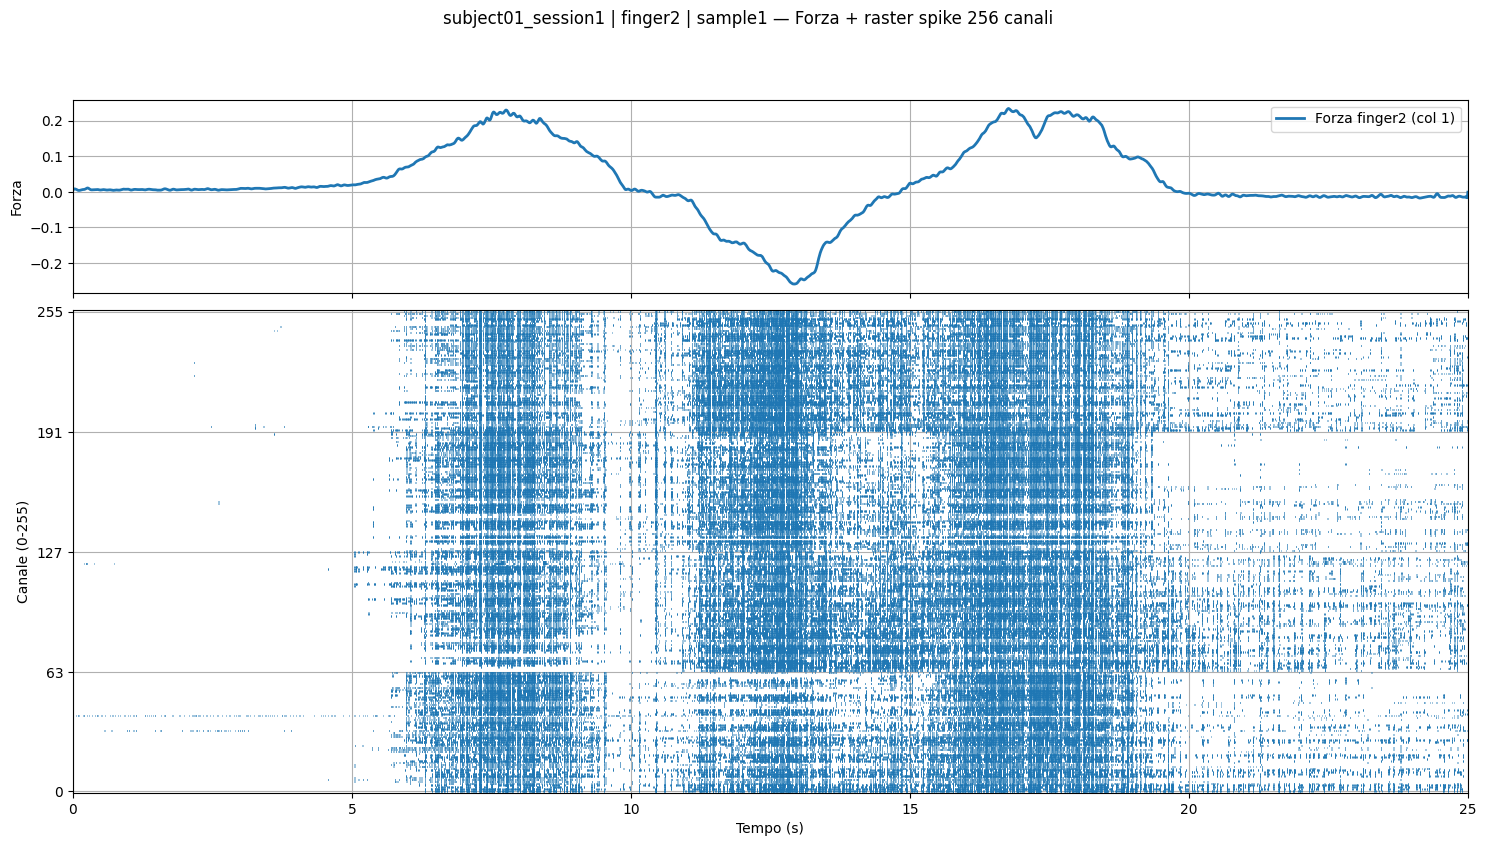

In [ ]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import wfdb
from scipy import signal
from math import gcd

plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['axes.grid'] = True

# --- riuso le tue funzioni (assumo siano già definite sopra) ---
# resample_to_target_fs, lowpass_zero_phase, load_emg_force, finger_to_force_col

def load_spikes_npz(spike_root, subj, finger, samp):
    p = Path(spike_root) / f"spikes_{subj}_{finger}_{samp}.npz"
    z = np.load(p, allow_pickle=True)
    pos = z["pos"].astype(bool)  # (T,256)
    neg = z["neg"].astype(bool)
    fs  = int(z["fs"]) if "fs" in z else 1000
    return pos, neg, fs

def plot_force_with_all_spike_raster(
    subj, finger, samp,
    spike_root,
    t_start=0.0, t_end=25.0,
    force_scale=None,   # None=auto
    figsize=(18, 9),
    lw_force=2.0,
    spike_ms=6,         # lunghezza trattino spike
):
    # --- forza (dal raw, così sei sicuro di allineare) ---
    fs_target = 1000
    X_emg, F_force = load_emg_force(subj, finger, samp, fs_target=fs_target)
    T = min(X_emg.shape[0], F_force.shape[0])
    F_force = F_force[:T]

    force_col = finger_to_force_col(finger)
    f = F_force[:, force_col]

    # --- spike (da npz) ---
    pos, neg, fs_spk = load_spikes_npz(spike_root, subj, finger, samp)
    Tsp = min(T, pos.shape[0])
    pos = pos[:Tsp]
    neg = neg[:Tsp]
    f   = f[:Tsp]

    fs = fs_target  # dovrebbe essere 1000 anche negli spike
    assert fs_spk == fs, f"FS mismatch: spikes fs={fs_spk} vs force fs={fs}"

    i0 = int(t_start * fs)
    i1 = min(int(t_end * fs), Tsp)
    t = np.arange(i0, i1) / fs
    f_win = f[i0:i1]
    pos_win = pos[i0:i1]  # (Tw,256)
    neg_win = neg[i0:i1]

    # --- prepara eventi per eventplot (più veloce che disegnare 256*Tw punti) ---
    # ogni canale -> lista tempi spike
    events_pos = [t[np.where(pos_win[:, ch])[0]] for ch in range(pos_win.shape[1])]
    events_neg = [t[np.where(neg_win[:, ch])[0]] for ch in range(neg_win.shape[1])]

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 3.0], hspace=0.05)

    # --- asse forza ---
    axF = fig.add_subplot(gs[0, 0])
    axF.plot(t, f_win, linewidth=lw_force, label=f"Forza {finger} (col {force_col})")
    axF.set_ylabel("Forza")
    axF.legend(loc="upper right")
    axF.set_xlim(t_start, t_end)
    if force_scale is not None:
        axF.set_ylim(force_scale[0], force_scale[1])

    # --- asse raster spike 256 canali ---
    axS = fig.add_subplot(gs[1, 0], sharex=axF)

    # POS e NEG sovrapposti (due passate). Eventplot mette una riga per canale.
    # lineoffsets = indice canale
    lineoffsets = np.arange(256)
    linelengths = 0.8  # altezza “trattino” relativa alla riga

    axS.eventplot(
        events_pos,
        lineoffsets=lineoffsets,
        linelengths=linelengths,
        linewidths=0.6,
        # colors: non imposto colori (come da regole), quindi default
    )
    axS.eventplot(
        events_neg,
        lineoffsets=lineoffsets,
        linelengths=linelengths,
        linewidths=0.6,
    )

    axS.set_ylim(-1, 256)
    axS.set_ylabel("Canale (0-255)")
    axS.set_xlabel("Tempo (s)")
    axS.set_yticks([0, 63, 127, 191, 255])
    axS.grid(True, axis="x")

    # migliora leggibilità: togli tick x sopra
    plt.setp(axF.get_xticklabels(), visible=False)

    plt.suptitle(f"{subj} | {finger} | {samp} — Forza + raster spike 256 canali", y=0.98)
    plt.tight_layout()
    plt.show()

# --- USO ---
spike_root = Path("../hyser_partial") / "spike_maps_updated_2"

subject_to_view = subjects[0]
finger_to_view  = "finger2"
sample_to_view  = "sample1"

plot_force_with_all_spike_raster(
    subject_to_view, finger_to_view, sample_to_view,
    spike_root=spike_root,
    t_start=0.0, t_end=25.0
)
